In [ ]:
"Analyzing Stock Market Volatility During Global Conflict Periods: A Data-Driven Approach"

In [2]:
pip install yfinance pandas numpy matplotlib seaborn

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 7.0 MB/s eta 0:00:00 MB/s eta 0:00:01
  DEPRECATION: Building 'multitasking' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'multitasking'. Discussion can be found at https://github.com/pypa/pip/issues/6334
  Created wheel for multitasking: filename=multitasking-0.0.12-py3-none-any.whl size=15548 sha256=ee8ce2f33ef164801cf2411ff34e0b1ada421679c3ff1fb1f2c4b58d6b96e744
  Stored in directory: /Users/sandeepr/Library/Caches/pip/wheels/1e/df/0f/e2bbb22d689b30c681feb5410ab64a2523437b34c8ecfc6476
Successfully built multitasking
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [yfinance]━━ 3/5 [curl_cffi]
N

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

In [2]:
# Downloading Tesla stock data


df = yf.download("TSLA", start="2015-01-01", end="2024-12-31")

df.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,
2015-01-02,14.620667,14.883333,14.217333,14.858000,71466000
2015-01-05,14.006000,14.433333,13.810667,14.303333,80527500
2015-01-06,14.085333,14.280000,13.614000,14.004000,93928500
2015-01-07,14.063333,14.318667,13.985333,14.223333,44526000
2015-01-08,14.041333,14.253333,14.000667,14.187333,51637500


In [3]:
df.reset_index(inplace=True)

In [ ]:
I used the yfinance library to extract historical stock price data for Tesla. The dataset contains daily stock price 
information including open, high, low, close prices, and trading volume. This dataset will help analyze market behavior 
during global conflict periods.

In [4]:
# Fixing MultiIndex Column Structure


df.columns = df.columns.get_level_values(0)

In [5]:
df.head()

Price,Date,Close,High,Low,Open,Volume
0,2015-01-02,14.620667,14.883333,14.217333,14.858000,71466000
1,2015-01-05,14.006000,14.433333,13.810667,14.303333,80527500
2,2015-01-06,14.085333,14.280000,13.614000,14.004000,93928500
3,2015-01-07,14.063333,14.318667,13.985333,14.223333,44526000
4,2015-01-08,14.041333,14.253333,14.000667,14.187333,51637500


The dataset initially contained multi-level column headers due to the structure of data fetched using the yfinance library. 
These were flattened into a single level to simplify data manipulation and analysis.

In [6]:
# Basic info

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2515 entries, 0 to 2514
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    2515 non-null   datetime64[ns]
 1   Close   2515 non-null   float64       
 2   High    2515 non-null   float64       
 3   Low     2515 non-null   float64       
 4   Open    2515 non-null   float64       
 5   Volume  2515 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 118.0 KB


The dataset contains historical stock price data with features such as Open, High, Low, Close prices, and trading Volume. 
The Date column is in datetime format, which will be useful for time-based analysis. There are no major missing values 
observed in the dataset.

In [7]:
# Statistical Summary

df.describe()

Price,Date,Close,High,Low,Open,Volume
count,2515,2515.000000,2515.000000,2515.000000,2515.000000,2.515000e+03
mean,2019-12-31 01:37:54.512922624,115.564847,118.127021,112.871415,115.578935,1.123272e+08
min,2015-01-02 00:00:00,9.578000,10.331333,9.403333,9.488000,1.062000e+07
25%,2017-07-01 12:00:00,17.185000,17.480000,16.888333,17.174334,6.681690e+07
50%,2019-12-31 00:00:00,28.502001,28.713333,27.333332,28.299999,9.286200e+07
75%,2022-06-29 12:00:00,220.178337,225.253334,215.294998,220.825005,1.298032e+08
max,2024-12-30 00:00:00,479.859985,488.540009,457.510010,475.899994,9.140820e+08
std,NaN,114.104456,116.747743,111.357651,114.169550,7.408223e+07


Descriptive statistics provide insights into the distribution of stock prices. The mean and standard deviation 
indicate the average price levels and variability, while minimum and maximum values highlight the range of stock price movements.

In [8]:
# Checking Missing Values

df.isnull().sum()

Price
Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

In [ ]:
Missing value analysis shows that the dataset has minimal or no null values, ensuring reliability for further analysis.

In [9]:
# Checking Date format

df['Date'] = pd.to_datetime(df['Date'])

In [ ]:
The Date column was converted to datetime format to enable time-based feature extraction and analysis such as identifying trends over time.

In [10]:
# Feature Engineering
# Creating 'Daily Return' Column

df['Daily Return'] = df['Close'].pct_change()

In [ ]:
Daily Return represents the percentage change in closing price compared to the previous day, 
helping to understand short-term market movements.

In [12]:
# Creating 'Price Range' Column

df['Price Range'] = df['High'] - df['Low']

In [ ]:
Price Range indicates the difference between the highest and lowest price of the day, reflecting daily market volatility.

In [14]:
# Creating 'Moving Averages' Column

df['MA_7'] = df['Close'].rolling(window=7).mean()
df['MA_30'] = df['Close'].rolling(window=30).mean()

In [ ]:
Moving averages help smooth out short-term fluctuations and highlight longer-term trends in stock prices.

In [16]:
# Creating 'Volatility' Column

df['Volatility'] = df['Close'].rolling(window=7).std()

In [ ]:
Volatility measures the degree of variation in stock prices over time, indicating market uncertainty.

In [17]:
# Creating Date Based Features

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['Day_Name'] = df['Date'].dt.day_name()

In [ ]:
Date-based features such as year, month, and day were extracted to enable time-based analysis 
and identify temporal patterns in stock price movements.

In [18]:
df.head()

Price,Date,Close,High,Low,Open,Volume,Daily Return,Price Range,MA_7,MA_30,Volatility,Year,Month,Day,Day_Name
0,2015-01-02,14.620667,14.883333,14.217333,14.858000,71466000,NaN,0.666000,NaN,NaN,NaN,2015,1,2,Friday
1,2015-01-05,14.006000,14.433333,13.810667,14.303333,80527500,-0.042041,0.622666,NaN,NaN,NaN,2015,1,5,Monday
2,2015-01-06,14.085333,14.280000,13.614000,14.004000,93928500,0.005664,0.665999,NaN,NaN,NaN,2015,1,6,Tuesday
3,2015-01-07,14.063333,14.318667,13.985333,14.223333,44526000,-0.001562,0.333334,NaN,NaN,NaN,2015,1,7,Wednesday
4,2015-01-08,14.041333,14.253333,14.000667,14.187333,51637500,-0.001564,0.252666,NaN,NaN,NaN,2015,1,8,Thursday


In [19]:
# Data Cleaning 
# Removing NaN Rows

df = df.dropna()

In [ ]:
Null values were generated due to rolling calculations such as moving averages and volatility. These rows were removed to ensure 
accuracy and consistency in further analysis.

In [20]:
# Verify Cleaning

df.isnull().sum()

Price
Date            0
Close           0
High            0
Low             0
Open            0
Volume          0
Daily Return    0
Price Range     0
MA_7            0
MA_30           0
Volatility      0
Year            0
Month           0
Day             0
Day_Name        0
dtype: int64

In [21]:
# Checking Shape ( No of Rows, No of Columns)

df.shape

(2486, 15)

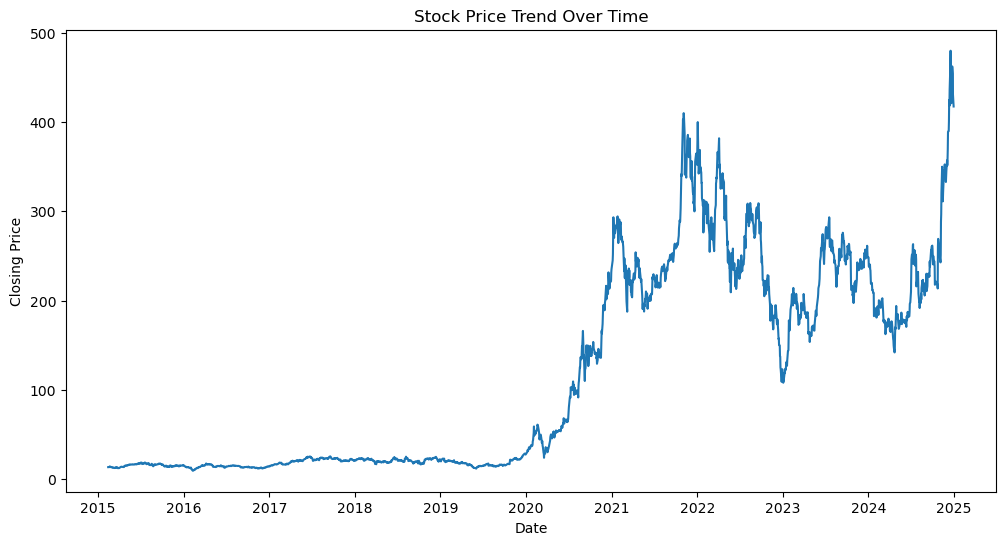

In [22]:
# Exploratory Data Analysis (EDA)
# Stock Price Trend

plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['Close'])
plt.title("Stock Price Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.show()

In [ ]:
The stock price trend over time shows fluctuations that may be influenced by external factors such as global conflicts. 
Significant spikes and drops indicate periods of market instability.

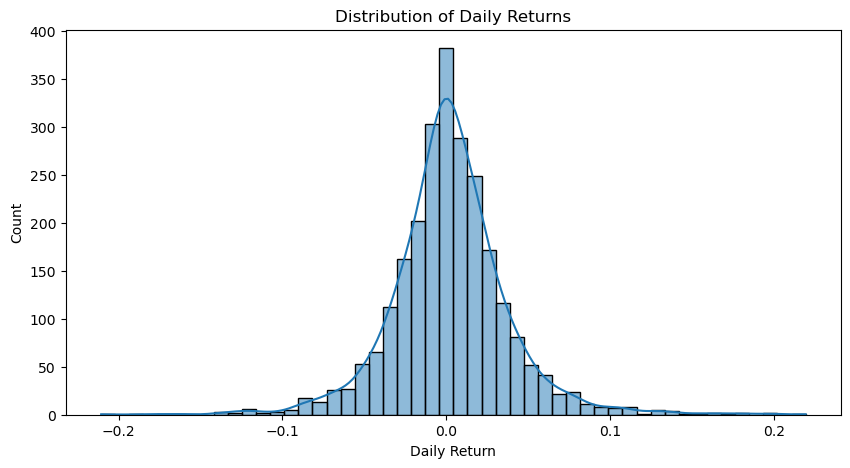

In [23]:
# Daily Return Distribution

plt.figure(figsize=(10,5))
sns.histplot(df['Daily Return'], bins=50, kde=True)
plt.title("Distribution of Daily Returns")
plt.show()

In [ ]:
The distribution of daily returns indicates the frequency of positive and negative returns, helping assess market risk and volatility.

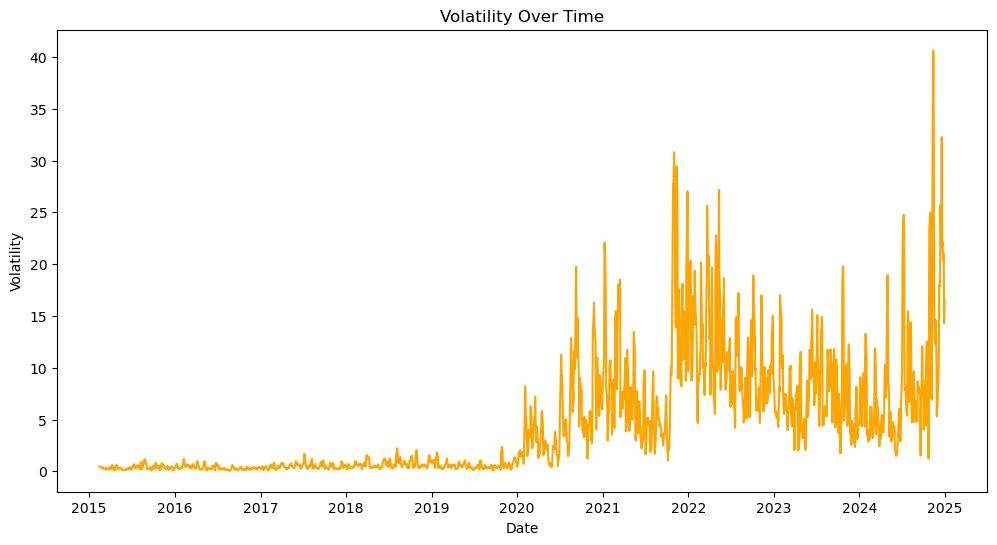

In [24]:
# Volatility Over Time

plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['Volatility'], color='orange')
plt.title("Volatility Over Time")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.show()

In [ ]:
Volatility trends highlight periods of increased uncertainty in the market, which may correspond to major global events or conflicts.

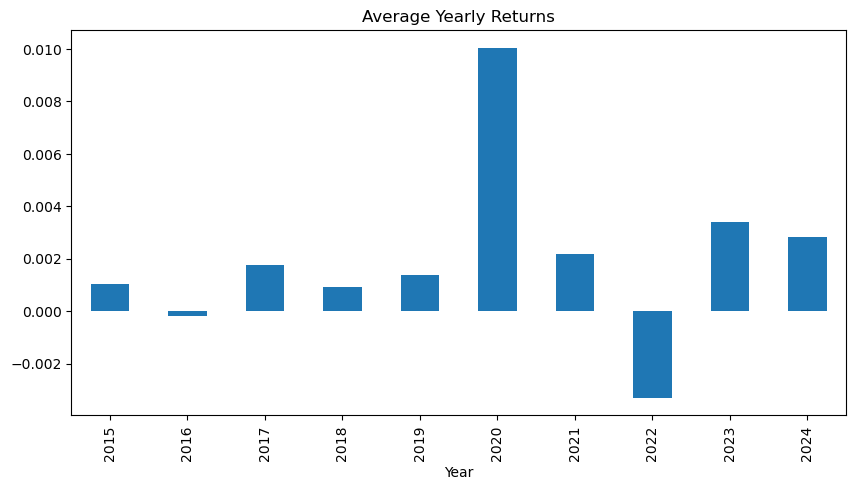

In [25]:
# Time Based Analysis
# Average Returns By Year

yearly_return = df.groupby('Year')['Daily Return'].mean()
yearly_return.plot(kind='bar', figsize=(10,5))
plt.title("Average Yearly Returns")
plt.show()

In [ ]:
Yearly return analysis helps identify periods of strong and weak market performance, which may be influenced by 
global economic and geopolitical factors.

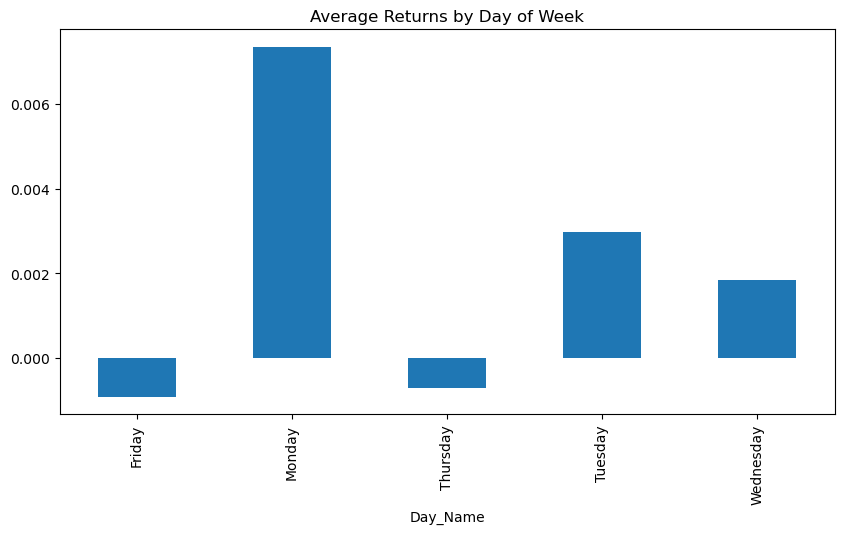

In [26]:
# Average Returns By Day

day_return = df.groupby('Day_Name')['Daily Return'].mean()

day_return.plot(kind='bar', figsize=(10,5))
plt.title("Average Returns by Day of Week")
plt.show()

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


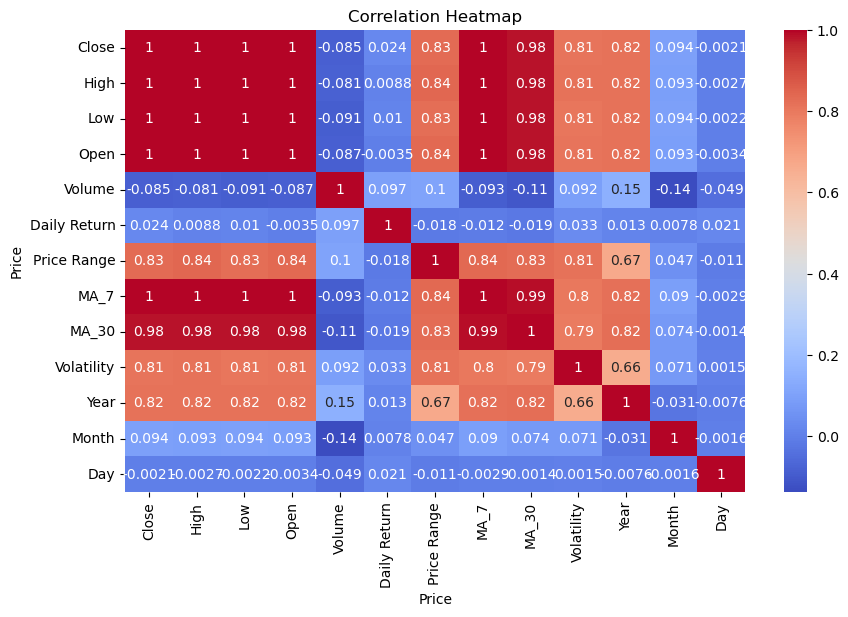

In [27]:
# Correlation Heatmap

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
The correlation heatmap illustrates relationships between different variables, helping identify patterns 
such as the relationship between volatility and returns.

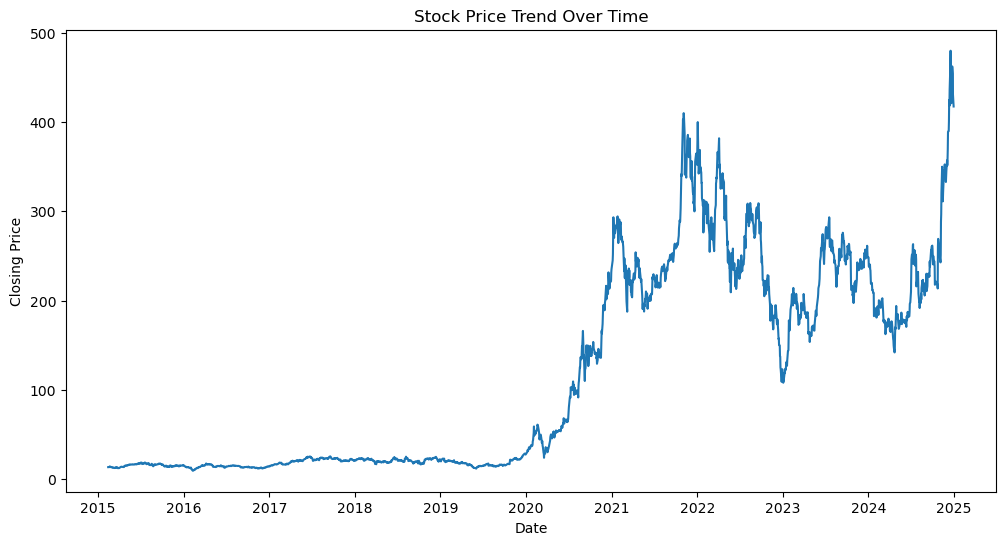

In [28]:
# PROBLEM STATEMENTS
# 1. How has the stock price changed over time?

plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['Close'])
plt.title("Stock Price Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.show()

In [ ]:
The stock price demonstrates noticeable fluctuations over time, with periods of both growth and decline. 
This suggests that the market is highly responsive to external factors such as economic shifts and 
global events, including conflict-related uncertainty.

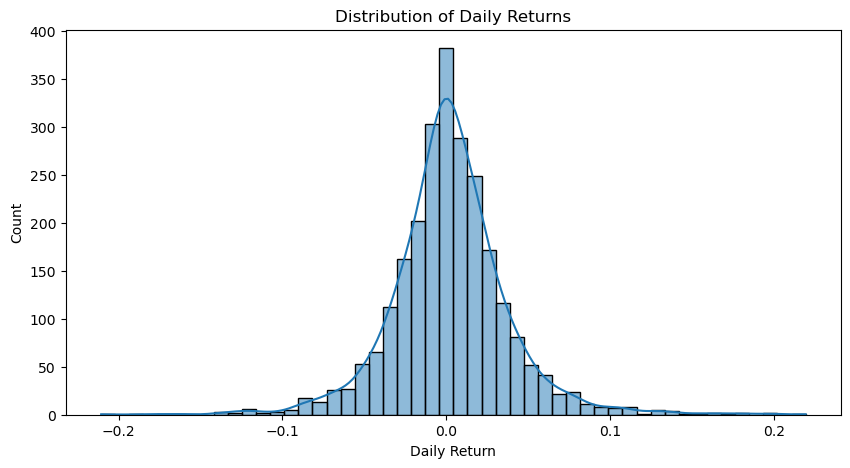

In [29]:
# 2. What is the distribution of daily returns?

plt.figure(figsize=(10,5))
sns.histplot(df['Daily Return'], bins=50, kde=True)
plt.title("Distribution of Daily Returns")
plt.show()

In [ ]:
The distribution of daily returns is concentrated around zero, indicating that most price movements are relatively small. 
However, the presence of extreme values indicates occasional sharp changes, which may be influenced by sudden market reactions.

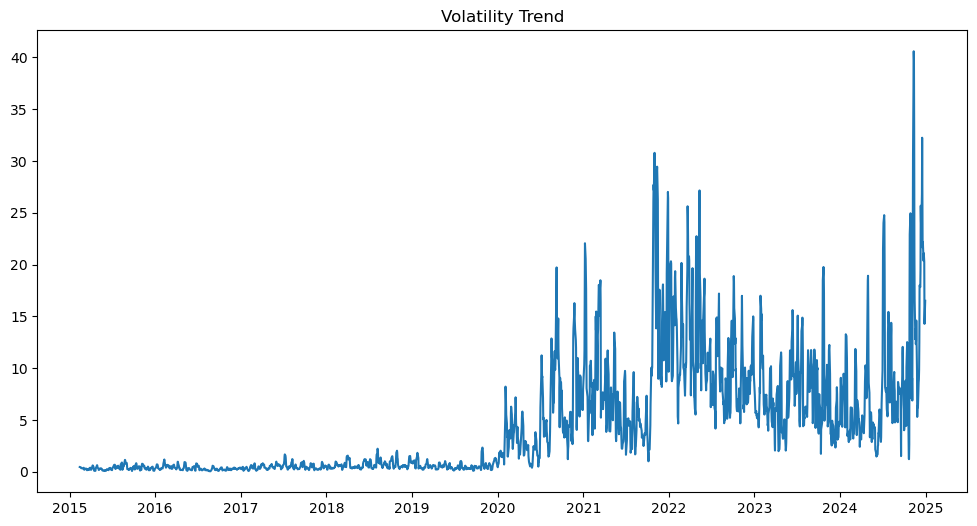

In [30]:
# 3. How does volatility change over time?

plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['Volatility'])
plt.title("Volatility Trend")
plt.show()

In [ ]:
The volatility trend highlights several spikes where price fluctuations increase significantly. This indicates periods
of heightened uncertainty, which may coincide with major geopolitical developments or global conflicts.

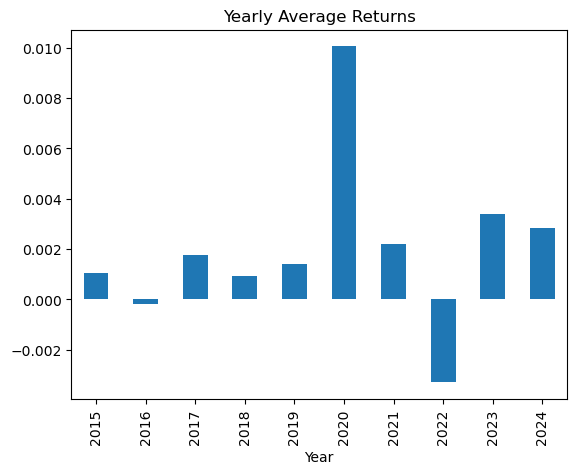

In [31]:
# 4. Which year had the highest average return?

df.groupby('Year')['Daily Return'].mean().plot(kind='bar')
plt.title("Yearly Average Returns")
plt.show()

In [ ]:
The variation in yearly average returns reflects differing market conditions across years. 
Some years show strong performance, while others indicate weaker returns, suggesting the 
influence of broader economic and global factors.

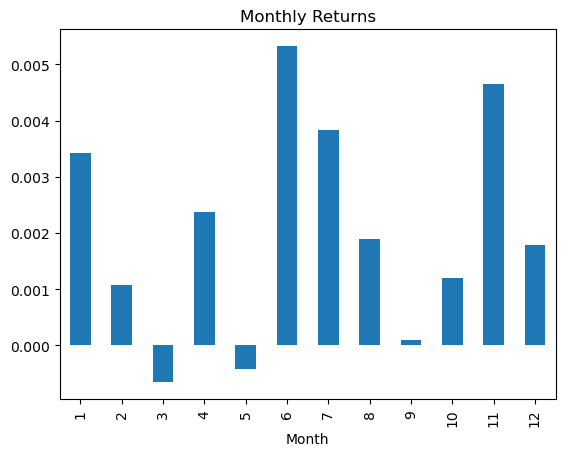

In [32]:
# 5. Which month performs best?

df.groupby('Month')['Daily Return'].mean().plot(kind='bar')
plt.title("Monthly Returns")
plt.show()

In [ ]:
Monthly return analysis reveals that certain months tend to perform better than others. 
This suggests the existence of seasonal patterns in stock market behavior, potentially influenced by recurring economic cycles.

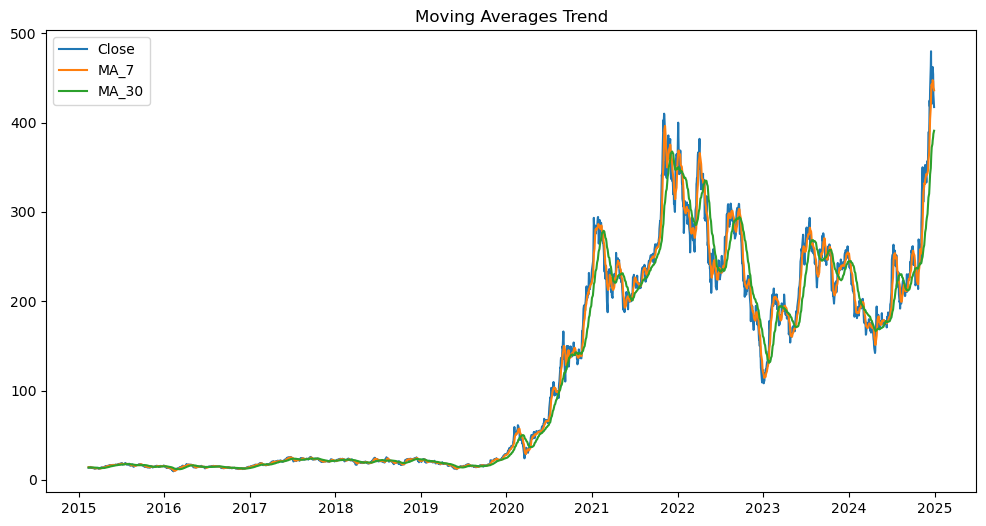

In [33]:
# 6. What is the trend of moving averages?

plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['Close'], label='Close')
plt.plot(df['Date'], df['MA_7'], label='MA_7')
plt.plot(df['Date'], df['MA_30'], label='MA_30')
plt.legend()
plt.title("Moving Averages Trend")
plt.show()

In [ ]:
The moving averages provide a clearer view of the underlying trend by smoothing short-term fluctuations. 
The relationship between short-term and long-term averages indicates shifts in market momentum over time.

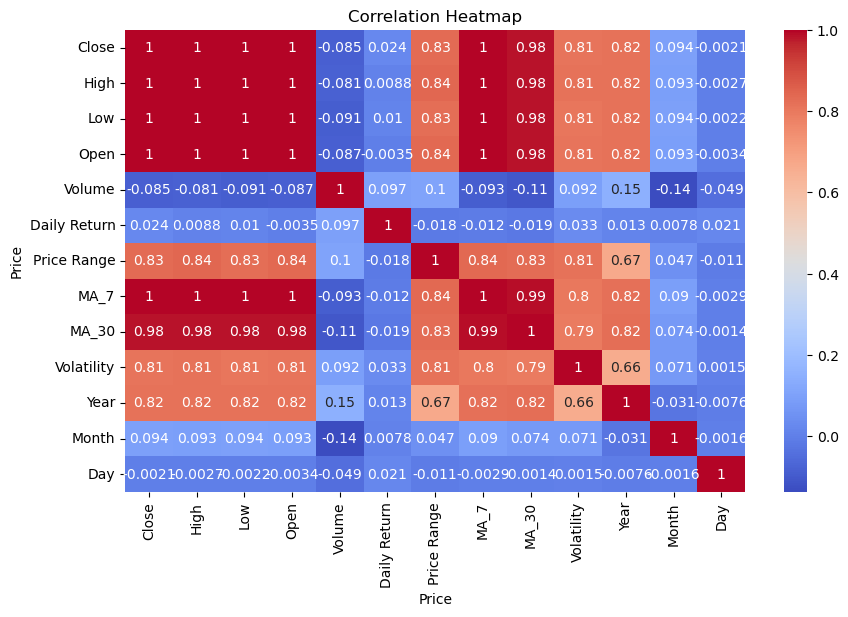

In [34]:
# 7. How are features correlated?

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
The correlation heatmap illustrates strong relationships between variables such as closing price and moving averages. 
It also indicates how volatility and returns interact, providing deeper insights into market dynamics.

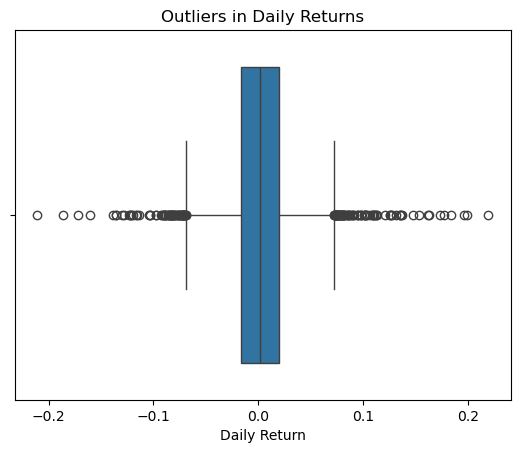

In [35]:
# 8. Are there extreme daily returns (outliers)?

sns.boxplot(x=df['Daily Return'])
plt.title("Outliers in Daily Returns")
plt.show()

In [ ]:
The presence of outliers in daily returns highlights extreme price movements. 
This may indicate sudden reactions to major events, including economic announcements or global conflict developments.

In [36]:
# 9. What is the average closing price?

df['Close'].mean()

np.float64(116.752026810343)

In [ ]:
The average closing price provides an overall benchmark of the stocks performance across the selected time period, 
indicating its general market value.

In [40]:
# 10. What is the maximum and minimum price

df['Close'].max()

479.8599853515625

In [41]:
df['Close'].min()

9.57800006866455

In [ ]:
The range between maximum and minimum prices reflects the extent of price variation. 
This indicates how widely the stock has fluctuated over time.

In [42]:
# 11. Which day had the highest trading volume?

df.loc[df['Volume'].idxmax()]

Price
Date            2020-02-04 00:00:00
Close                     59.137333
High                      64.599335
Low                       55.591999
Open                      58.863998
Volume                    914082000
Daily Return               0.137256
Price Range                9.007336
MA_7                      44.422381
MA_30                     34.918467
Volatility                 8.230141
Year                           2020
Month                             2
Day                               4
Day_Name                    Tuesday
Name: 1280, dtype: object

In [ ]:
The day with the highest trading volume represents a peak in market activity. 
This suggests increased investor participation, possibly driven by significant news or events.

In [43]:
# 12. What is the average return per year?

df.groupby('Year')['Daily Return'].mean()

Year
2015    0.001055
2016   -0.000161
2017    0.001748
2018    0.000932
2019    0.001391
2020    0.010047
2021    0.002188
2022   -0.003293
2023    0.003387
2024    0.002849
Name: Daily Return, dtype: float64

In [ ]:
The yearly average returns highlight how the stock performed across different time periods. 
This indicates variations in market conditions and investor sentiment year by year.

In [44]:
# 13. What is the most volatile day?

df.loc[df['Volatility'].idxmax()]

Price
Date            2024-11-11 00:00:00
Close                         350.0
High                     358.640015
Low                           336.0
Open                     346.299988
Volume                    210521600
Daily Return               0.089596
Price Range               22.640015
MA_7                     285.702857
MA_30                    249.729001
Volatility                40.597454
Year                           2024
Month                            11
Day                              11
Day_Name                     Monday
Name: 2481, dtype: object

In [ ]:
The most volatile day reflects the highest level of price fluctuation within a single day. 
This suggests a strong market reaction, potentially triggered by unexpected events.

In [46]:
# 14. Which month has the highest average return?

df.groupby('Month')['Daily Return'].mean().idxmax()

np.int32(6)

In [ ]:
The month with the highest average return indicates a period where the stock consistently performs well. 
This suggests a possible seasonal advantage during that time.

In [47]:
# 15. What is the correlation between return and volatility?

df['Daily Return'].corr(df['Volatility'])

np.float64(0.033163209337879314)

In [ ]:
The relationship between daily returns and volatility highlights how price movements are associated with market uncertainty. 
This indicates that larger fluctuations often occur during more volatile periods.

In [48]:
df.to_csv("stock_data.csv", index=False)

In [49]:
# Installing Required Library


!pip install mysql-connector-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 2.0 MB/s eta 0:00:00 MB/s eta 0:00:01:01


In [50]:
#Connecting to MySql

import mysql.connector

conn = mysql.connector.connect(
    host="localhost",
    user="root",          # your MySQL username
    password="Passsword",
    database="stock_analysis"
)

In [51]:
#Loading Data into Pandas

import pandas as pd

query = "SELECT * FROM stock_data"
df_sql = pd.read_sql(query, conn)

df_sql.head()

/var/folders/cz/_rt03fg90wlc_g43ml4jh6_w0000gn/T/ipykernel_2319/3475326230.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_sql = pd.read_sql(query, conn)


,Date,Open,High,Low,Close,Volume,Daily_Return,Price_Range,MA_7,MA_30,Volatility,Year,Month,Day,Day_Name
0,2015-02-13,13.5267,13.7327,13.3940,13.5847,92865000,0.004387,0.338667,14.2054,13.7878,0.472460,2015,2,13,Friday
1,2015-02-17,13.7133,13.7133,13.4333,13.6233,59694000,0.002846,0.280000,14.0470,13.7546,0.451731,2015,2,17,Tuesday
2,2015-02-18,13.6113,13.7447,13.5067,13.6307,40704000,0.000538,0.238000,13.9241,13.7421,0.427223,2015,2,18,Wednesday
3,2015-02-19,13.6667,14.1627,13.5833,14.1140,77311500,0.035459,0.579334,13.8691,13.7430,0.360535,2015,2,19,Thursday
4,2015-02-20,14.0520,14.5067,13.9873,14.4740,89731500,0.025507,0.519334,13.8770,13.7567,0.374750,2015,2,20,Friday
